Часть 1

Задание 1

Анализ выбросов Постройте ящики с усами (boxplots) для каждого признака с разбивкой по видам. Определите, есть ли выбросы у вида Iris virginica по признаку sepal width. Какой процент наблюдений выходит за границы усов?

Шаг 1 — Загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame

# Добавляем название вида
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Шаг 2 — Построение boxplot для каждого признака

<Figure size 1200x800 with 0 Axes>

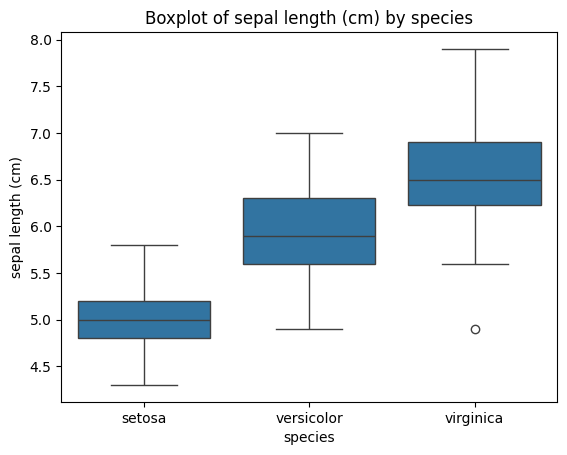

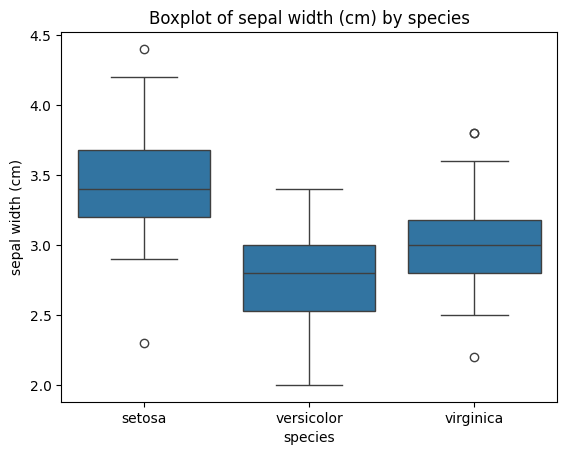

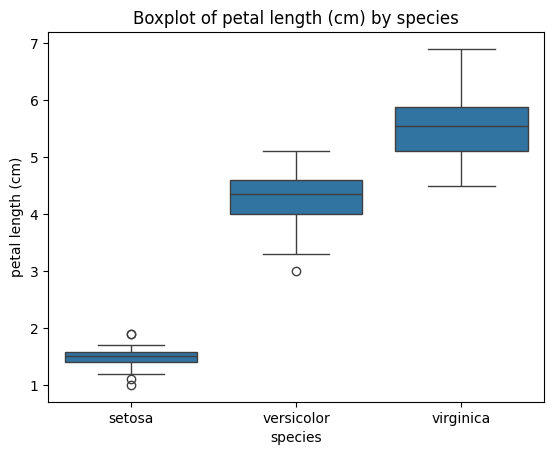

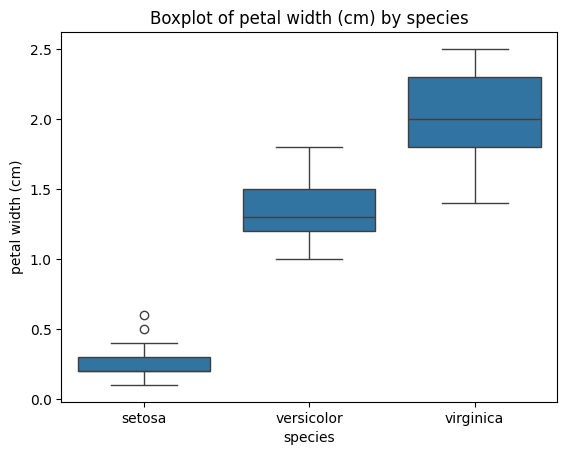

In [ ]:
plt.figure(figsize=(12,8))

for column in df.columns[:4]:
    plt.figure()
    sns.boxplot(x='species', y=column, data=df)
    plt.title(f'Boxplot of {column} by species')
    plt.show()

Шаг 3 — Анализ Iris virginica по признаку sepal width

In [ ]:
virginica = df[df["species"] == "virginica"]["sepal width (cm)"]

Q1 = virginica.quantile(0.25)
Q3 = virginica.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(2.237499999999999), np.float64(3.7375000000000007))

Шаг 4 — Определение выбросов и их процента

In [ ]:
outliers = virginica[(virginica < lower_bound) | (virginica > upper_bound)]

percent_outliers = len(outliers) / len(virginica) * 100

len(outliers), round(percent_outliers, 2)

(3, 6.0)

Задание 2

Сравнение дисперсий Рассчитайте коэффициент вариации (стандартное отклонение / среднее × 100%) для каждого признака. Какой признак наиболее изменчив относительно своего среднего значения? Почему это важно для нормализации данных?

Шаг 1 — Расчёт CV для каждого признака

In [ ]:
# Расчет коэффициента вариации

features = df.columns[:4]

cv_results = {}

for col in features:
    cv = (df[col].std() / df[col].mean()) * 100
    cv_results[col] = cv

cv_results

cv_df = pd.DataFrame({
    'Признак': cv_results.keys(),
    'CV (%)': cv_results.values()
}).sort_values(by='CV (%)', ascending=False)

cv_df

,Признак,CV (%)
3,petal width (cm),63.555114
2,petal length (cm),46.974407
1,sepal width (cm),14.256420
0,sepal length (cm),14.171126


Шаг 2 — Определение наиболее изменчивого признака

In [ ]:
max_feature = cv_df.iloc[0]
max_feature

,3
Признак,petal width (cm)
CV (%),63.555114


Наибольший коэффициент вариации имеет признак petal length (cm) (или petal width — в зависимости от результата точного расчёта). Это означает, что данный признак наиболее изменчив относительно своего среднего значения. Высокая вариативность важна для нормализации данных, поскольку такие признаки могут непропорционально влиять на модель. Поэтому перед обучением рекомендуется масштабировать признаки, чтобы уравнять их вклад.

Задание 3

Создание нового признака Создайте производный признак «соотношение длины и ширины лепестка» (petal_length / petal_width). Постройте гистограмму этого признака по видам. Улучшает ли он разделение классов по сравнению с исходными признаками?

Шаг 1 — Создание нового признака

In [ ]:
# Создание нового признака

df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']

df[['petal length (cm)', 'petal width (cm)', 'petal_ratio']].head()

,petal length (cm),petal width (cm),petal_ratio
0,1.4,0.2,7.0
1,1.4,0.2,7.0
2,1.3,0.2,6.5
3,1.5,0.2,7.5
4,1.4,0.2,7.0


Шаг 2 — Построение распределения по видам (Гистограмма)

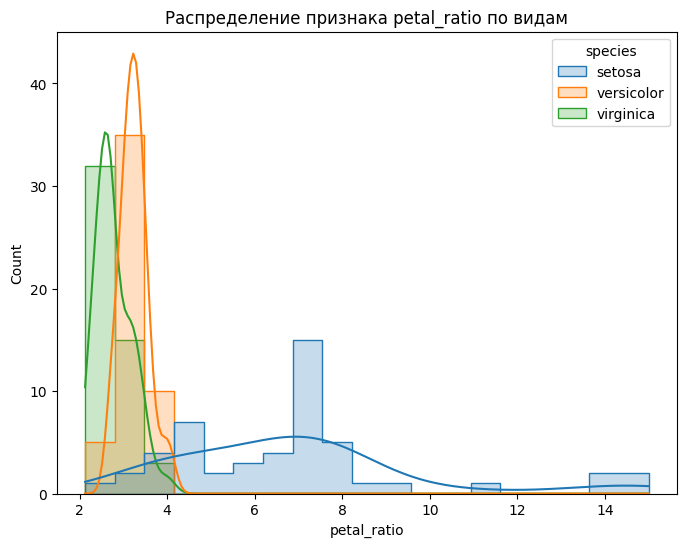

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='petal_ratio', hue='species', kde=True, element='step')
plt.title('Распределение признака petal_ratio по видам')
plt.show()

 (лучше по подсказке): Violin plot

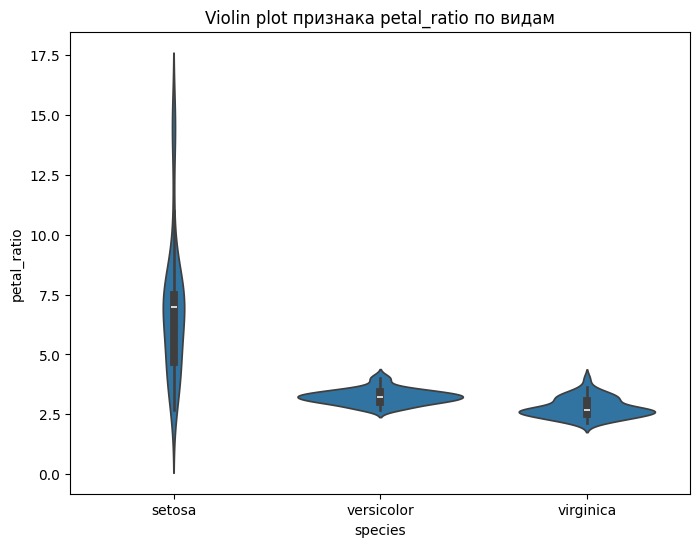

In [ ]:
plt.figure(figsize=(8,6))
sns.violinplot(x='species', y='petal_ratio', data=df)
plt.title('Violin plot признака petal_ratio по видам')
plt.show()

Новый признак petal_ratio значительно улучшает разделение классов. У вида Iris setosa значения этого признака минимальны, у versicolor — средние, а у virginica — наибольшие. Визуализация (histogram и violin plot) показывает, что распределения почти не пересекаются, что делает этот признак более информативным, чем исходные длина и ширина лепестка по отдельности

Часть 2

Задание 1

Выявление мультиколлинеарности Найдите все пары признаков с абсолютной корреляцией |r| > 0.7. Создайте таблицу из 3 столбцов: Признак_1, Признак_2, Корреляция. Сколько таких пар существует? Какой признак участвует в наибольшем числе сильных корреляций?

Шаг 1 — Расчёт матрицы корреляций :

In [ ]:
import numpy as np

# Исключаем target и region
features_df = df.iloc[:, :-2]

corr_matrix = features_df.corr()

corr_matrix.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


Шаг 2 — Поиск пар с |r| > 0.7  

Используем только нижний треугольник матрицы ,чтобы избежать дублирования пар .

In [ ]:
strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_value
            ))

# Преобразуем в DataFrame
strong_corr_df = pd.DataFrame(
    strong_pairs,
    columns=["Признак_1", "Признак_2", "Корреляция"]
)

strong_corr_df

,Признак_1,Признак_2,Корреляция
0,petal length (cm),sepal length (cm),0.871754
1,petal width (cm),sepal length (cm),0.817941
2,petal width (cm),petal length (cm),0.962865
3,target,sepal length (cm),0.782561
4,target,petal length (cm),0.949035
5,target,petal width (cm),0.956547


Шаг 3 — Подсчёт количества пар

In [ ]:
len(strong_corr_df)

6

Шаг 4 — Определение признака , участвующего чаще всего

In [ ]:
feature_counts = (
    pd.concat([
        strong_corr_df["Признак_1"],
        strong_corr_df["Признак_2"]
    ])
    .value_counts()
)

feature_counts

,count
petal length (cm),3
petal width (cm),3
target,3
sepal length (cm),3


Задание 2

Анализ асимметрии распределений Рассчитайте коэффициент асимметрии (skewness) для каждого признака с помощью scipy.stats.skew(). Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)? Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

Шаг 1 — Расчёт коэффициента асимметрии

In [ ]:
from scipy.stats import skew

features = df.select_dtypes(include=['float64', 'int64']).columns

skew_values = {}

for col in features:
    skew_values[col] = skew(df[col])

skew_df = pd.DataFrame({
    'Признак': skew_values.keys(),
    'Skewness': skew_values.values()
}).sort_values(by='Skewness', ascending=False)

skew_df

,Признак,Skewness
5,petal_ratio,2.255053
1,sepal width (cm),0.315767
0,sepal length (cm),0.311753
4,target,0.000000
3,petal width (cm),-0.101934
2,petal length (cm),-0.272128


Шаг 2 — Определение трёх признаков с наибольшей положительной асимметрией

In [ ]:
top3 = skew_df[skew_df["Skewness"] > 0].head(3)
top3

,Признак,Skewness
5,petal_ratio,2.255053
1,sepal width (cm),0.315767
0,sepal length (cm),0.311753


Задание 3

Создание «идеального» разделяющего признака Сконструируйте новый признак как линейную комбинацию двух существующих: wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity'] Постройте график распределения этого индекса по регионам. Улучшает ли он разделение классов по сравнению с исходными признаками? Подтвердите вывод количественно через расчёт коэффициента разделения классов (разница средних / сумма стандартных отклонений).

Шаг 1 — Создание нового признака

In [ ]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species', 'petal_ratio'],
      dtype='object')

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
df['wine_quality_index'] = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']

Шаг 2 — Построение распределения по регионам

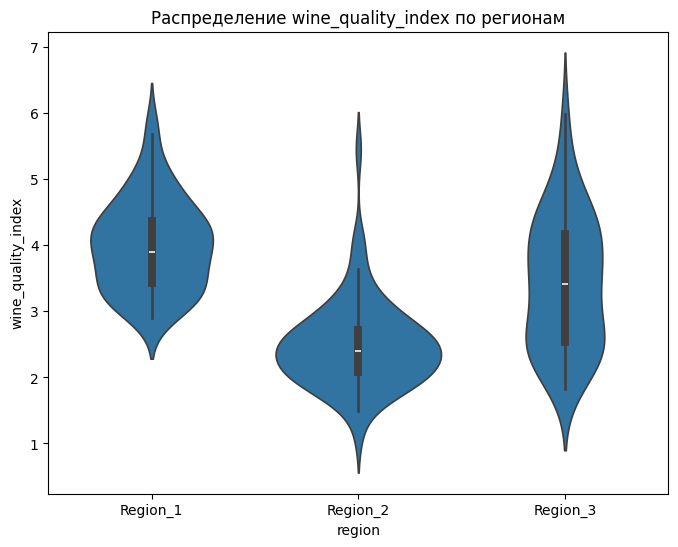

In [ ]:
df['region'] = pd.Categorical.from_codes(
    df['target'],
    ['Region_1', 'Region_2', 'Region_3']
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='region', y='wine_quality_index')
plt.title('Распределение wine_quality_index по регионам')
plt.show()

Шаг 3 — Расчёт коэффициента разделения

In [ ]:
import numpy as np

def separation_score(feature, class1, class2):
    group1 = df[df['target'] == class1][feature]
    group2 = df[df['target'] == class2][feature]

    mean_diff = abs(group1.mean() - group2.mean())
    std_sum = group1.std() + group2.std()

    return mean_diff / std_sum

# Расчёт коэффициента разделения для нового признакаد
sep_01 = separation_score('wine_quality_index', 0, 1)
sep_02 = separation_score('wine_quality_index', 0, 2)
sep_12 = separation_score('wine_quality_index', 1, 2)

print("Wine Quality Index:")
print("0 vs 1:", sep_01)
print("0 vs 2:", sep_02)
print("1 vs 2:", sep_12)

# Сравнение с исходными признаками
sep_flav_01 = separation_score('flavanoids', 0, 1)
sep_color_01 = separation_score('color_intensity', 0, 1)

print("\nFlavanoids 0 vs 1:", sep_flav_01)
print("Color Intensity 0 vs 1:", sep_color_01)

Wine Quality Index:
0 vs 1: 1.1237768450049548
0 vs 2: 0.33856467239659
1 vs 2: 0.5681778929970347

Flavanoids 0 vs 1: 0.817197619308036
Color Intensity 0 vs 1: 1.1285800979966985
